# Inference Server Client — CIFAR-10
Запускаем MLServer и Triton последовательно, измеряем latency и throughput, сравниваем.

## 1. Импорты и данные

In [1]:
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
import tritonclient.http as triton_http

CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog",      "frog",       "horse", "ship", "truck",
]
MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32).reshape(3, 1, 1)
STD  = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32).reshape(3, 1, 1)

MODEL_NAME  = "resnet18_cifar10"
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
N_WARMUP    = 10
N_RUNS      = 200
N_BENCH     = 50

_cifar_path = Path("../section_2/data/cifar-10-batches-py/test_batch")
with open(_cifar_path, "rb") as f:
    _batch = pickle.load(f, encoding="bytes")

_images    = _batch[b"data"].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
VAL_IMAGES = (_images - MEAN) / STD
VAL_LABELS = _batch[b"labels"]

img, label = VAL_IMAGES[0], VAL_LABELS[0]
x = img[np.newaxis]  # (1, 3, 32, 32)

print(f"Val images : {VAL_IMAGES.shape}")
print(f"Sample     : {CLASSES[label]} (idx 0)")

Val images : (10000, 3, 32, 32)
Sample     : cat (idx 0)


/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_96757/1555588839.py:25: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  _batch = pickle.load(f, encoding="bytes")


## 2. MLServer — localhost:8080
Запустить сервер: `./mlserver/run_mlserver_docker.sh`

In [2]:
MLSERVER_URL = "http://localhost:8080"

live  = requests.get(f"{MLSERVER_URL}/v2/health/live").ok
ready = requests.get(f"{MLSERVER_URL}/v2/health/ready").ok
meta  = requests.get(f"{MLSERVER_URL}/v2/models/{MODEL_NAME}").json()

print(f"Live    : {live}")
print(f"Ready   : {ready}")
print(f"Model   : {meta['name']}")
print(f"Inputs  : {[i['name'] for i in meta['inputs']]}")
print(f"Outputs : {[o['name'] for o in meta['outputs']]}")

Live    : True
Ready   : True
Model   : resnet18_cifar10
Inputs  : []
Outputs : []


In [3]:
payload = {
    "inputs": [{
        "name":     "image",
        "shape":    list(x.shape),
        "datatype": "FP32",
        "data":     x.flatten().tolist(),
    }]
}

resp   = requests.post(f"{MLSERVER_URL}/v2/models/{MODEL_NAME}/infer", json=payload)
logits = np.array(resp.json()["outputs"][0]["data"], dtype=np.float32)
pred   = logits.argmax()
probs  = np.exp(logits) / np.exp(logits).sum()

print(f"True label : {CLASSES[label]}")
print(f"Predicted  : {CLASSES[pred]}")
print(f"Confidence : {probs[pred]:.1%}")

True label : cat
Predicted  : cat
Confidence : 77.7%


In [4]:
# MLServer V2 accepts JSON only — binary_data=False
ml_client = triton_http.InferenceServerClient(url="localhost:8080")
ml_inp    = triton_http.InferInput("image", x.shape, "FP32")
ml_inp.set_data_from_numpy(x, binary_data=False)
ml_out = triton_http.InferRequestedOutput("logits", binary_data=False)

for _ in range(N_WARMUP):
    ml_client.infer(MODEL_NAME, inputs=[ml_inp], outputs=[ml_out])

times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    ml_client.infer(MODEL_NAME, inputs=[ml_inp], outputs=[ml_out])
    times.append((time.perf_counter() - t0) * 1000)

ml_lat = np.array(times)
print(f"MLServer latency (batch=1, n={N_RUNS})")
print(f"  mean : {ml_lat.mean():.2f} ms")
print(f"  p50  : {np.percentile(ml_lat, 50):.2f} ms")
print(f"  p95  : {np.percentile(ml_lat, 95):.2f} ms")
print(f"  p99  : {np.percentile(ml_lat, 99):.2f} ms")

ml_throughputs   = []
ml_latencies_p50 = []

print(f"\n{'Batch':>5}  {'Lat p50':>9}  {'Throughput':>12}")
print("-" * 32)

for bs in BATCH_SIZES:
    x_b   = np.repeat(x, bs, axis=0)
    inp_b = triton_http.InferInput("image", x_b.shape, "FP32")
    inp_b.set_data_from_numpy(x_b, binary_data=False)
    out_b = triton_http.InferRequestedOutput("logits", binary_data=False)

    for _ in range(5):
        ml_client.infer(MODEL_NAME, inputs=[inp_b], outputs=[out_b])

    t_list = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        ml_client.infer(MODEL_NAME, inputs=[inp_b], outputs=[out_b])
        t_list.append(time.perf_counter() - t0)

    lat = np.percentile(t_list, 50) * 1000
    tps = bs / np.mean(t_list)
    ml_latencies_p50.append(lat)
    ml_throughputs.append(tps)
    print(f"{bs:>5}  {lat:>7.1f} ms  {tps:>10.0f} img/s")

MLServer latency (batch=1, n=200)
  mean : 27.60 ms
  p50  : 25.36 ms
  p95  : 41.45 ms
  p99  : 57.38 ms

Batch    Lat p50    Throughput
--------------------------------
    1     29.6 ms          33 img/s
    2     42.4 ms          47 img/s
    4     63.3 ms          62 img/s
    8    102.2 ms          77 img/s
   16    164.5 ms          97 img/s
   32    285.1 ms         111 img/s


## 3. Triton — localhost:8000
Запустить сервер: `./triton/run_triton.sh`

In [5]:
TRITON_URL = "http://localhost:8000"

live  = requests.get(f"{TRITON_URL}/v2/health/live").ok
ready = requests.get(f"{TRITON_URL}/v2/health/ready").ok
meta  = requests.get(f"{TRITON_URL}/v2/models/{MODEL_NAME}").json()

print(f"Live    : {live}")
print(f"Ready   : {ready}")
print(f"Model   : {meta['name']}")
print(f"Inputs  : {[i['name'] for i in meta['inputs']]}")
print(f"Outputs : {[o['name'] for o in meta['outputs']]}")

Live    : True
Ready   : True
Model   : resnet18_cifar10
Inputs  : ['image']
Outputs : ['logits']


In [6]:
payload = {
    "inputs": [{
        "name":     "image",
        "shape":    list(x.shape),
        "datatype": "FP32",
        "data":     x.flatten().tolist(),
    }]
}

resp   = requests.post(f"{TRITON_URL}/v2/models/{MODEL_NAME}/infer", json=payload)
logits = np.array(resp.json()["outputs"][0]["data"], dtype=np.float32)
pred   = logits.argmax()
probs  = np.exp(logits) / np.exp(logits).sum()

print(f"True label : {CLASSES[label]}")
print(f"Predicted  : {CLASSES[pred]}")
print(f"Confidence : {probs[pred]:.1%}")

True label : cat
Predicted  : cat
Confidence : 77.7%


In [7]:
# Triton supports binary encoding — faster than JSON
tr_client = triton_http.InferenceServerClient(url="localhost:8000")
tr_inp    = triton_http.InferInput("image", x.shape, "FP32")
tr_inp.set_data_from_numpy(x, binary_data=True)
tr_out = triton_http.InferRequestedOutput("logits", binary_data=True)

for _ in range(N_WARMUP):
    tr_client.infer(MODEL_NAME, inputs=[tr_inp], outputs=[tr_out])

times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    tr_client.infer(MODEL_NAME, inputs=[tr_inp], outputs=[tr_out])
    times.append((time.perf_counter() - t0) * 1000)

tr_lat = np.array(times)
print(f"Triton latency (batch=1, n={N_RUNS})")
print(f"  mean : {tr_lat.mean():.2f} ms")
print(f"  p50  : {np.percentile(tr_lat, 50):.2f} ms")
print(f"  p95  : {np.percentile(tr_lat, 95):.2f} ms")
print(f"  p99  : {np.percentile(tr_lat, 99):.2f} ms")

tr_throughputs   = []
tr_latencies_p50 = []

print(f"\n{'Batch':>5}  {'Lat p50':>9}  {'Throughput':>12}")
print("-" * 32)

for bs in BATCH_SIZES:
    x_b   = np.repeat(x, bs, axis=0)
    inp_b = triton_http.InferInput("image", x_b.shape, "FP32")
    inp_b.set_data_from_numpy(x_b, binary_data=True)
    out_b = triton_http.InferRequestedOutput("logits", binary_data=True)

    for _ in range(5):
        tr_client.infer(MODEL_NAME, inputs=[inp_b], outputs=[out_b])

    t_list = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        tr_client.infer(MODEL_NAME, inputs=[inp_b], outputs=[out_b])
        t_list.append(time.perf_counter() - t0)

    lat = np.percentile(t_list, 50) * 1000
    tps = bs / np.mean(t_list)
    tr_latencies_p50.append(lat)
    tr_throughputs.append(tps)
    print(f"{bs:>5}  {lat:>7.1f} ms  {tps:>10.0f} img/s")

Triton latency (batch=1, n=200)
  mean : 22.76 ms
  p50  : 20.86 ms
  p95  : 37.75 ms
  p99  : 46.08 ms

Batch    Lat p50    Throughput
--------------------------------
    1     22.1 ms          45 img/s
    2     38.9 ms          51 img/s
    4     59.5 ms          67 img/s
    8     95.4 ms          83 img/s
   16    159.3 ms         100 img/s
   32    265.2 ms         118 img/s


## 4. Сравнение

/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_96757/2948314255.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


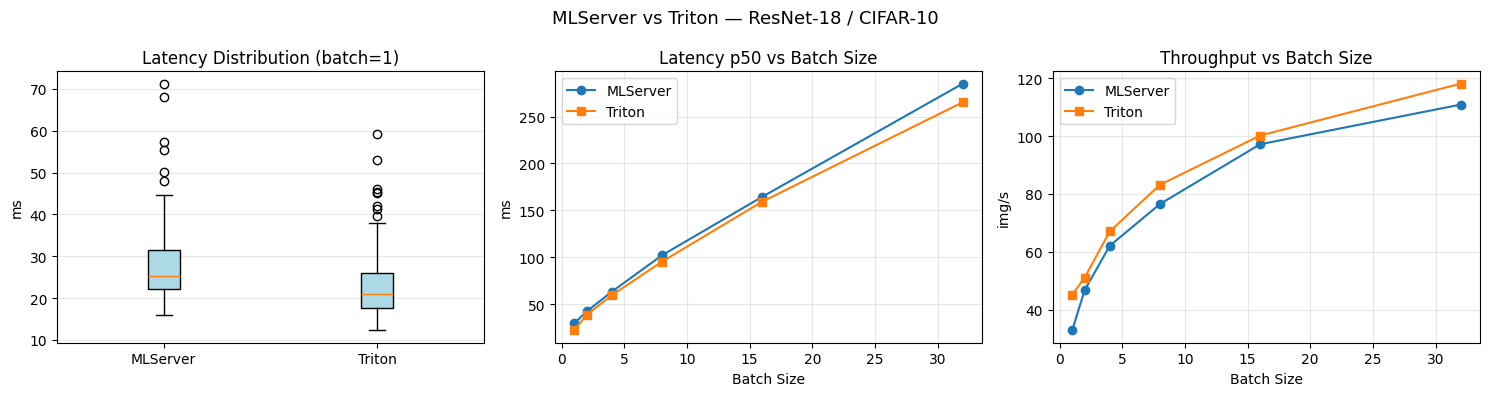

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(
    [ml_lat, tr_lat],
    labels=["MLServer", "Triton"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
)
axes[0].set(title="Latency Distribution (batch=1)", ylabel="ms")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(BATCH_SIZES, ml_latencies_p50, marker="o", label="MLServer")
axes[1].plot(BATCH_SIZES, tr_latencies_p50, marker="s", label="Triton")
axes[1].set(title="Latency p50 vs Batch Size", xlabel="Batch Size", ylabel="ms")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(BATCH_SIZES, ml_throughputs, marker="o", label="MLServer")
axes[2].plot(BATCH_SIZES, tr_throughputs, marker="s", label="Triton")
axes[2].set(title="Throughput vs Batch Size", xlabel="Batch Size", ylabel="img/s")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("MLServer vs Triton — ResNet-18 / CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()